## Import Libraries

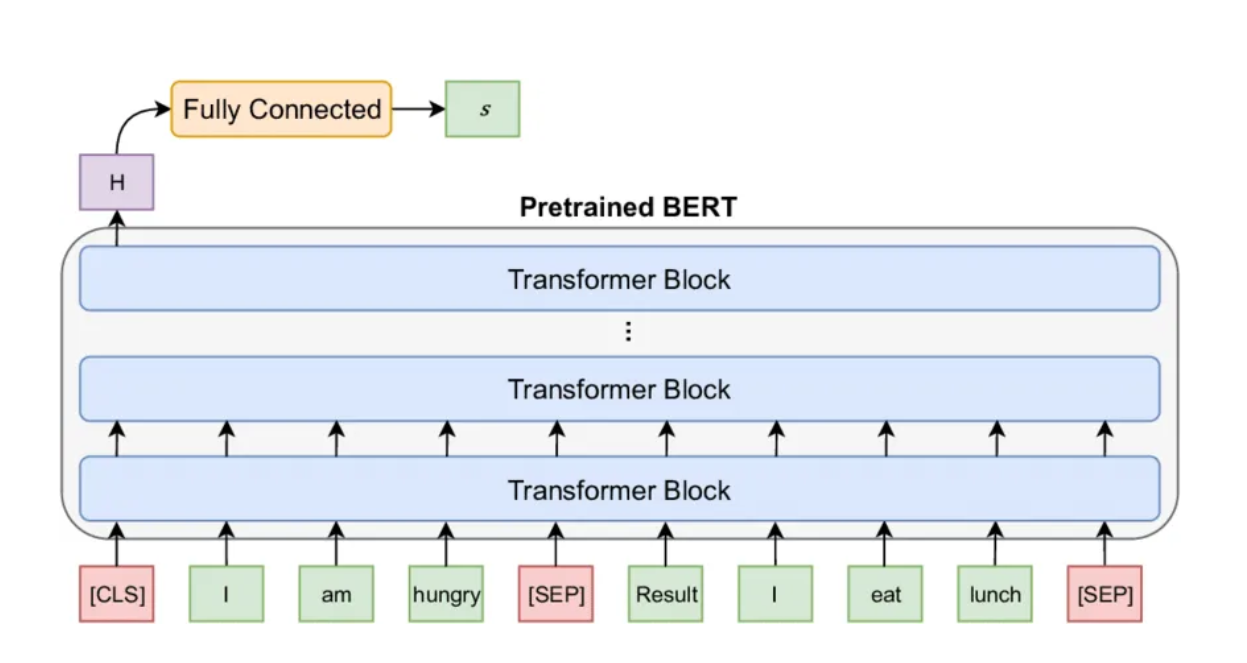
- https://medium.com/@pyroswolf200/fine-tuning-bert-on-imdb-review-dataset-309e90b6dac0

The IMDb Movie Reviews dataset is a binary sentiment analysis dataset consisting of 50,000 reviews from the Internet Movie Database (IMDb) labeled as positive or negative. In this article we will try to classify film review sentences as good or bad.

#### Without all the model, just loading from HG

In [79]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, RandomSampler
from transformers import  BertTokenizer ,BertModel
from tqdm import tqdm
from datasets import load_dataset




# from transformers import BertForSequenceClassification
# from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [80]:
import sys
sys.path.append('./src') #link to GTL libraries
import src.guided_transfer_learning as gtl

In [81]:
# Load pre-trained BERT model and adding a dense layer  
bert = BertModel.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

################################################################
## Note:
# We can load BertForSequenceClassification, but when loadin we get the message: " Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']" ,so it is better to use this method
################################

# Define custom model architecture
class ClassificationBERT(nn.Module):
    def __init__(self, bert, num_labels, trainable_bert=False):
        super().__init__()
        self.trainable_bert = trainable_bert
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(bert.config.hidden_size, num_labels) # bert.config.hidden_size = 768

        # Set requires_grad=True for fine-tuning BERT
        if trainable_bert == True:
            for param in self.bert.parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.dropout(pooled_output)
        logits = self.classifier(output)
        return logits
    
# Initialize model, loss_function, and optimizer
num_labels = 2
model = ClassificationBERT(bert, num_labels,trainable_bert=False) 

# Move model to device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Device: ', device)
model.to(device)

Device:  cpu


ClassificationBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

In [82]:
# Load the IMDB dataset
imdb_dataset = load_dataset('imdb')

In [83]:
# Define a preprocessing function to tokenize the text and encode it as input ids and attention masks 
def imdb_preprocess_function(examples):
    # inputs = tokenizer(examples['text'], truncation=True, padding='max_length', return_tensors='pt')
    inputs = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=64, add_special_tokens=True, return_attention_mask=True, return_tensors='pt')
    return {'input_ids': inputs['input_ids'].squeeze(), 'attention_mask': inputs['attention_mask'].squeeze(), 'labels': torch.tensor(examples['label'])}

In [84]:
# Convert datasets to torch Dataset
class CustomDatasetClass(Dataset):
    def __init__(self, dataset):
        self.input_ids = dataset['input_ids']
        self.attention_mask = dataset['attention_mask']
        self.labels = dataset['labels']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [109]:
limit = 20 # Select only the first 'limit' samples from train and test sets for quick testing
imdb_train_dataset = imdb_dataset['train'].select(range(limit)) # type: ignore
imdb_test_dataset = imdb_dataset['test'].select(range(limit)) # type: ignore

In [110]:
# Define a preprocessing function to tokenize the text and encode it as input ids and attention masks
def imdb_preprocess_function(examples):
    # inputs = tokenizer(examples['text'], truncation=True, padding='max_length', return_tensors='pt')
    inputs = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=64, add_special_tokens=True, return_attention_mask=True, return_tensors='pt')
    return {'input_ids': inputs['input_ids'].squeeze(), 'attention_mask': inputs['attention_mask'].squeeze(), 'labels': torch.tensor(examples['label'])}

In [111]:
# Preprocess the train and test datasets
imdb_train_dataset = imdb_train_dataset.map(imdb_preprocess_function, batched=True)
imdb_test_dataset = imdb_test_dataset.map(imdb_preprocess_function, batched=True)

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [112]:
# Convert datasets to torch Dataset
class CustomDatasetClass(Dataset):
    def __init__(self, dataset):
        self.input_ids = dataset['input_ids']
        self.attention_mask = dataset['attention_mask']
        self.labels = dataset['labels']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

imdb_train_dataset = CustomDatasetClass(imdb_train_dataset)
imdb_test_dataset = CustomDatasetClass(imdb_test_dataset)

In [113]:
# Define the batch size and other data loader parameters
batch_size = 8
shuffle = True
num_workers = 0
epochs = 1

train_random_sampler = RandomSampler(imdb_train_dataset, num_samples=5)
test_random_sampler = RandomSampler(imdb_test_dataset, num_samples=5)

# Create data loaders for training and testing datasets
imdb_train_loader = DataLoader(imdb_train_dataset, batch_size=batch_size,sampler=train_random_sampler)
imdb_test_loader = DataLoader(imdb_test_dataset, batch_size=batch_size, sampler=test_random_sampler)

In [114]:
# Define the optimizer and loss function
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_function = nn.CrossEntropyLoss()
# Define the training function
def train_model(model, optimizer, train_loader, loss_function, epochs, verbose=True, with_GTL=False, guidance_matrix=None):
    """
    Trains the model for a specified number of epochs.

    Args:
        model: The model to train.
        optimizer: The optimizer to use for training.
        train_loader: The data loader for the training dataset.
        loss_function: The loss function to use for training.
        epochs: The number of epochs to train for.
        verbose: Whether to print training progress.
        with_GTL: Whether to use guidance matrix for training.
        guidance_matrix: The guidance matrix to use for training.

    Returns:
        A list of the average loss for each epoch.
    """
    skip = 5000 if epochs > 10000 else 500 if epochs > 1000 else 50 if epochs > 100 else 5 if epochs > 10 else 1
    model.train() # Set the model to training mode
    loss_vals = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in tqdm(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = loss_function(outputs, labels)
            model.zero_grad()
            loss.backward()
            if with_GTL and guidance_matrix is None:
                print('Guidance matrix is not provided')
                return None
            if with_GTL and guidance_matrix is not None:
                gtl.apply_guidance(model, guidance_matrix)
            optimizer.step()
            epoch_loss += loss.item()
        loss_vals.append(epoch_loss / len(train_loader))
        if verbose and ((epoch+1)%skip  == 0 or epoch == 0 or epoch == epochs-1):
            print(f'Epoch: {epoch} - Training loss: {epoch_loss / len(train_loader)}')
    return loss_vals

# Define the evaluation function
def evaluate_model(model, test_loader, loss_function):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: The data loader for the test dataset.
        loss_function: The loss function to use for evaluation.

    Returns:
        The average loss and accuracy on the test dataset.
    """
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for batch in tqdm(test_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = loss_function(outputs, labels)
            total_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            total_acc += (predictions == labels).sum().item()
    avg_loss = total_loss / len(test_loader)
    accuracy = total_acc / len(test_loader.dataset) * 100
    print(f'Test loss: {avg_loss} Test acc: {accuracy}%')
    return avg_loss, accuracy

# Define the plotting function
def plot_loss(numbers):
    """
    Plots a line graph of the given numbers against the epochs.
    Args:
    numbers (list): A list of numbers representing the loss values for each epoch.
    Returns:
    None: This function does not return any value. It only displays a plot.
    """
 
    plt.figure(figsize=(8, 5)) 
    plt.plot(range(1, len(numbers) + 1), numbers, marker='o', linestyle='-')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Plot of Numbers')
    plt.grid(True)
    plt.show()

In [115]:
imdb_train_losses = train_model(model, optimizer, imdb_train_loader, loss_function, epochs=3,with_GTL=False)
# evaluate_model(model, test_loader, loss_function)

100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


Epoch: 0 - Training loss: 0.4923807978630066


100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Epoch: 1 - Training loss: 0.41089946031570435


100%|██████████| 1/1 [00:00<00:00,  1.53it/s]

Epoch: 2 - Training loss: 0.3560623526573181


In [116]:
imdb_avg_loss, imdb_accuracy = evaluate_model(model,imdb_test_loader,loss_function) 

100%|██████████| 1/1 [00:00<00:00,  4.41it/s]

Test loss: 0.31995877623558044 Test acc: 25.0%


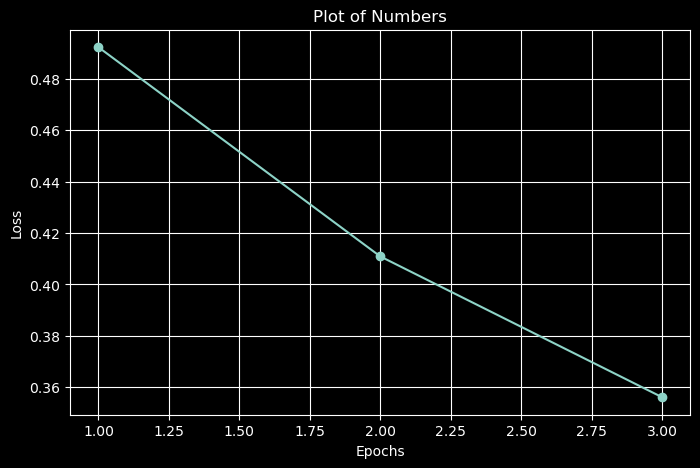

In [117]:
plot_loss(imdb_train_losses)

#### Get Dataset for training the Guidance matrix

In [94]:
goemotions_dataset = load_dataset('go_emotions')

In [101]:
goemotions_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [131]:
limit = 20 # Select only the first 'limit' samples from train and test sets for quick testing
goemotions_train_dataset = goemotions_dataset['train'].select(range(limit)) # type: ignore
goemotions_test_dataset = goemotions_dataset['test'].select(range(limit)) # type: ignore

In [132]:
# Define a preprocessing function to tokenize the text and encode it as input ids and attention masks
def goemotions_preprocess_function(examples):
    # inputs = tokenizer(examples['text'], truncation=True, padding='max_length', return_tensors='pt')
    inputs = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=64, add_special_tokens=True, return_attention_mask=True, return_tensors='pt')
    new_labels = [example[0] for example in examples['labels']]
    return {'input_ids': inputs['input_ids'].squeeze(), 'attention_mask': inputs['attention_mask'].squeeze(), 'labels': torch.tensor(new_labels)}

In [133]:
# Preprocess the train and test datasets
goemotions_train_dataset = goemotions_train_dataset.map(goemotions_preprocess_function, batched=True)
goemotions_test_dataset = goemotions_test_dataset.map(goemotions_preprocess_function, batched=True)

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [134]:
goemotions_train_dataset = CustomDatasetClass(goemotions_train_dataset)
goemotions_test_dataset = CustomDatasetClass(goemotions_test_dataset)

In [135]:
train_random_sampler = RandomSampler(goemotions_train_dataset, num_samples=10)
test_random_sampler = RandomSampler(goemotions_train_dataset, num_samples=4)


# Create data loaders for training and testing datasets
goemotions_train_loader = DataLoader(goemotions_train_dataset,batch_size=8,sampler=train_random_sampler)
goemotions_test_loader = DataLoader(goemotions_test_dataset, batch_size=8, sampler=test_random_sampler)

#### Guidance Matrix

In [136]:
bert = BertModel.from_pretrained('bert-base-uncased')
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_function = nn.CrossEntropyLoss()

In [137]:
scout_random_sampler = RandomSampler(goemotions_train_dataset, num_samples=10)
goemotions_scout_loader = DataLoader(goemotions_train_dataset,batch_size=8,sampler=scout_random_sampler)

In [144]:
num_labels = 28
ClassificationBERT_2 = ClassificationBERT(bert, num_labels, trainable_bert=False).to(device) 
my_scouts = gtl.create_scouts(ClassificationBERT_2, should_save_guidance=True,should_save_scouts=False, use_squared_differences=True,)


In [145]:
my_scouts

In [146]:
goemotions_train_losses = train_model(ClassificationBERT_2, optimizer, goemotions_scout_loader, loss_function, epochs=1)
my_scouts.add_scout(ClassificationBERT_2) 


100%|██████████| 2/2 [00:02<00:00,  1.08s/it]

Epoch: 0 - Training loss: 3.305959701538086


In [147]:
# for s in range(len(scout_data_X)):
#     print("scout number:", s) 
#     gtl.load_base(ClassificationBERT) # ------------using gtl library to newly load base model for each scout
#     train_model(ClassificationBERT, optimizer, goemotions_scout_loader, loss_function, epochs=1)
#     my_scouts.add_scout(ClassificationBERT) # ------------using gtl library to add scout data to the object    
# print("A total of", len(my_scouts), "scouts trained") 


guidance_matrix = my_scouts.create_raw_guidance(device) 
gtl.save_guidance_matrix(guidance_matrix)  # type: ignore 
del my_scouts 
del guidance_matrix 

#### Fine Tuning

## Testing